### **Dawar Ahmed** 
### **24I2533**
### **DS5B**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("food_delivery_orders.csv")

df.head()

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


# **Bivariate** 

### **Task 01** 

In [3]:
print("Skewness:", df['delivery_time_min'].skew())
print("Mean:", df['delivery_time_min'].mean())
print("Median:", df['delivery_time_min'].median())
print("Mode:", df['delivery_time_min'].mode().iloc[0])

Skewness: 2.8770611473024483
Mean: 34.541809523809526
Median: 32.5
Mode: 30.0


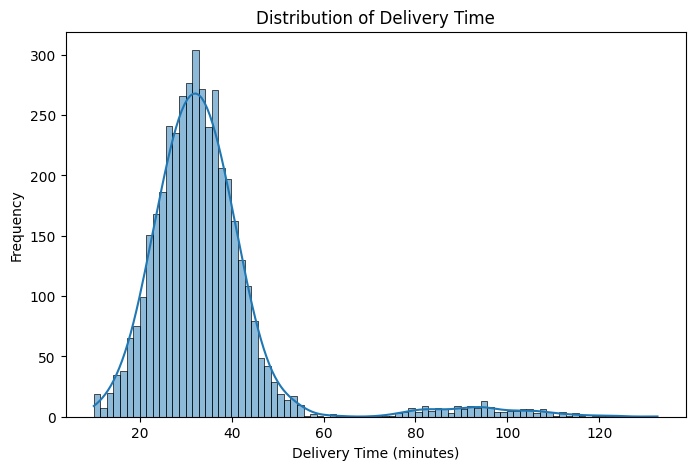

In [6]:
plt.figure(figsize=(8, 5))

sns.histplot(df['delivery_time_min'], kde=True)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")

plt.show()

#### The median is a more honest number to advertise because the delivery times are strongly right-skewed. The unusually long deliveries pull the mean upward, while the median better represents a typical delivery.

### **Task 02** 

#### **Violen Plot** 

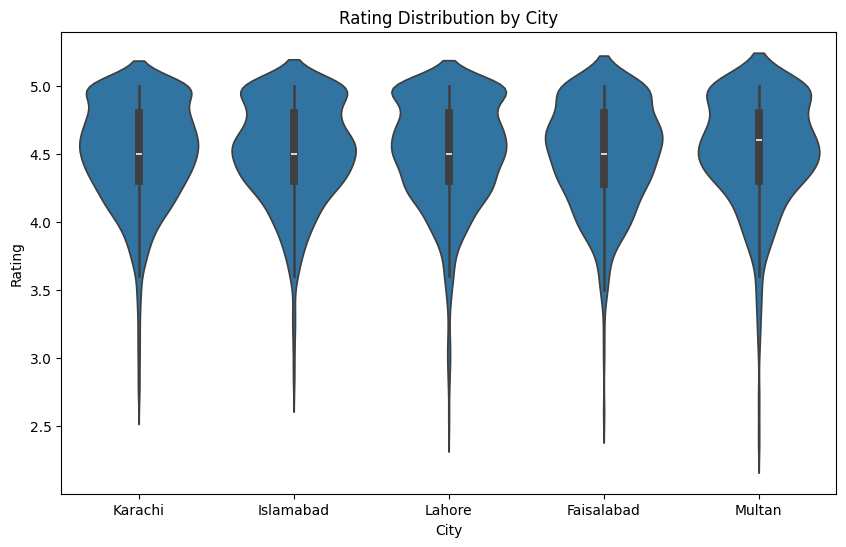

In [7]:
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x='city', y='rating')

plt.xlabel("City")
plt.ylabel("Rating")
plt.title("Rating Distribution by City")

plt.show()

#### **Strip Plot**

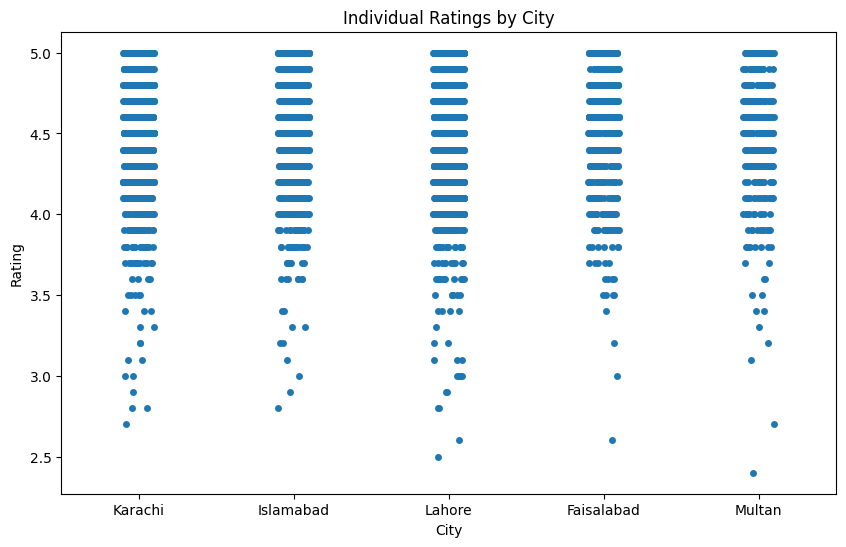

In [8]:
plt.figure(figsize=(10, 6))

sns.stripplot(data=df, x='city', y='rating', jitter=True)

plt.xlabel("City")
plt.ylabel("Rating")
plt.title("Individual Ratings by City")

plt.show()

In [9]:
df.groupby('city')['rating'].agg(['mean', 'std', 'min', 'max'])

,mean,std,min,max
city,,,,
Faisalabad,4.490041,0.384213,2.6,5.0
Islamabad,4.512216,0.373966,2.8,5.0
Karachi,4.508255,0.380484,2.7,5.0
Lahore,4.511027,0.396755,2.5,5.0
Multan,4.520984,0.400584,2.4,5.0


#### Multan shows the most inconsistent customer experience because its ratings have the widest spread and extend to the lowest values. The violin and strip plots show greater variability in Multan compared with the other cities.

# **Multi-Variate**

### **Task 03** 

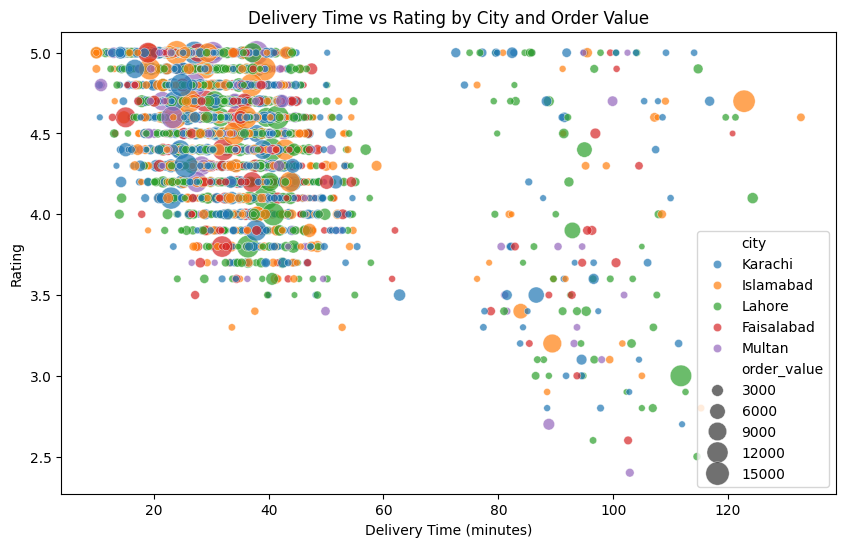

In [12]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    hue='city',
    size='order_value',
    sizes=(20, 300),
    alpha=0.7
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating by City and Order Value")

plt.show()

#### High-value orders tend to have faster delivery times and better ratings. This pattern is visible because order value is encoded by bubble size while city is shown using color.

### **Task 04** 

In [13]:
numeric_df = df.select_dtypes(include='number')
numeric_df.head()

,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2768.0,25.0,36.2,4.5,95.0
1,4979.0,44.8,23.3,4.8,-437.0
2,4008.0,11.9,39.6,4.2,618.0
3,3260.0,8.3,35.8,4.5,423.0
4,435.0,13.5,29.4,4.8,53.0


In [ ]:
pearson_corr = numeric_df.corr(method='pearson')
pearson_corr

,order_value,discount_percent,delivery_time_min,rating,profit_per_order
order_value,1.000000,-0.011191,0.002202,0.003122,-0.657144
discount_percent,-0.011191,1.000000,0.013286,-0.006129,-0.081982
delivery_time_min,0.002202,0.013286,1.000000,-0.445474,-0.030879
rating,0.003122,-0.006129,-0.445474,1.000000,0.014360
profit_per_order,-0.657144,-0.081982,-0.030879,0.014360,1.000000


In [15]:
spearman_corr = numeric_df.corr(method='spearman')
spearman_corr

,order_value,discount_percent,delivery_time_min,rating,profit_per_order
order_value,1.000000,0.007783,-0.020271,0.004487,0.673114
discount_percent,0.007783,1.000000,0.019502,-0.002619,-0.380515
delivery_time_min,-0.020271,0.019502,1.000000,-0.412735,-0.108586
rating,0.004487,-0.002619,-0.412735,1.000000,0.052351
profit_per_order,0.673114,-0.380515,-0.108586,0.052351,1.000000


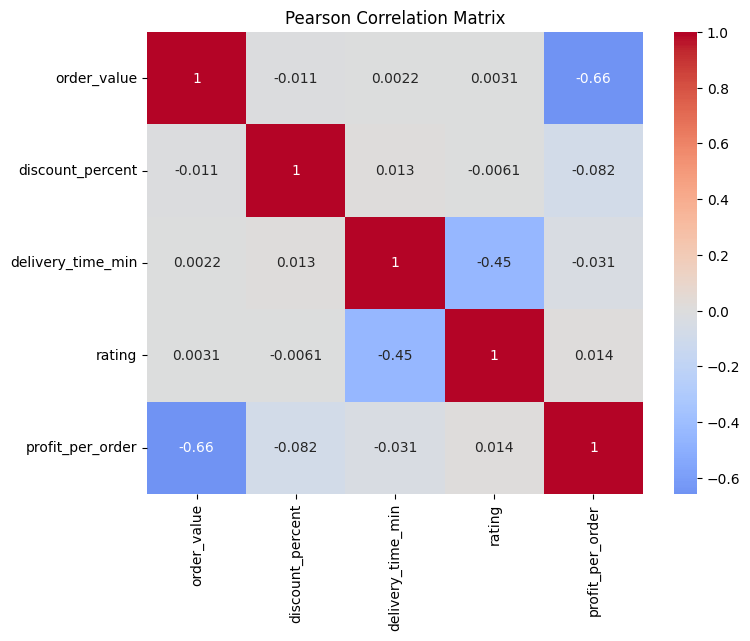

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Pearson Correlation Matrix")
plt.show()

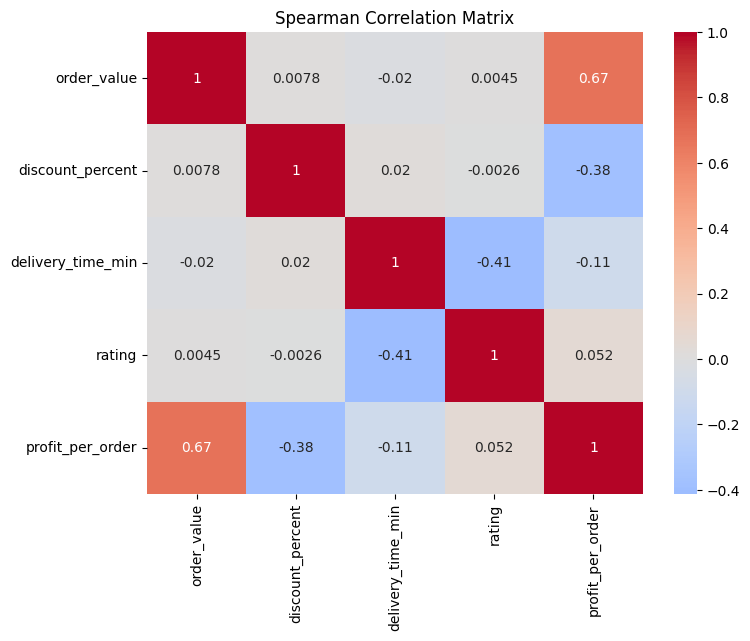

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0)
plt.title("Spearman Correlation Matrix")
plt.show()

#### The largest disagreement is between order_value and profit_per_order, with Pearson correlation of -0.66 and Spearman correlation of +0.67. The disagreement is mainly caused by a small number of extreme high-value orders with very large negative profits, so these orders should be investigated and only excluded if they are confirmed to be abnormal or erroneous. Correlation does not imply causation.

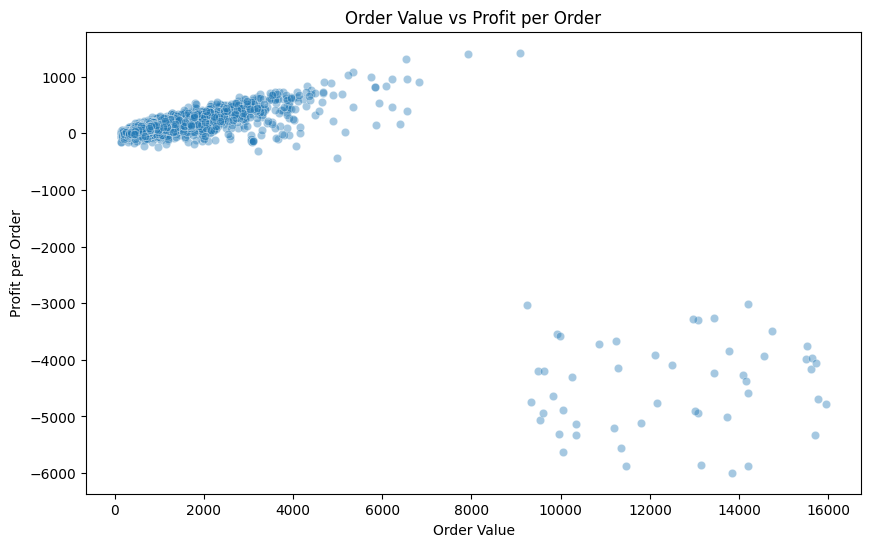

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='order_value',
    y='profit_per_order',
    alpha=0.4
)

plt.xlabel("Order Value")
plt.ylabel("Profit per Order")
plt.title("Order Value vs Profit per Order")

plt.show()

### **Task 05** 

In [21]:
profit_pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='profit_per_order',
    aggfunc='mean',
    margins=True
)

profit_pivot

restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining,All
city,,,,,,
Faisalabad,67.295455,65.779748,-70.312281,20.222750,293.695652,51.891636
Islamabad,-13.499649,57.011427,-27.884178,37.177258,153.117851,35.491634
Karachi,-38.901838,136.745480,75.240260,15.375665,302.801418,74.101668
Lahore,52.345680,137.614221,65.515000,10.618693,159.818290,71.552572
Multan,60.137931,-82.783323,55.865385,-40.784432,285.181818,12.622372
All,14.648580,91.829915,31.277856,13.613870,228.922310,57.370067


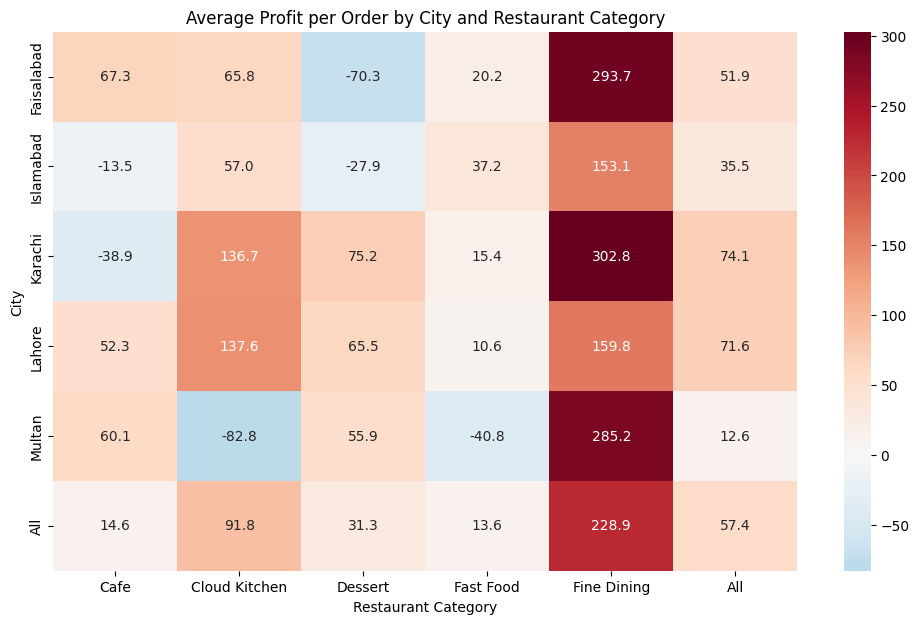

In [22]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    profit_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0
)

plt.xlabel("Restaurant Category")
plt.ylabel("City")
plt.title("Average Profit per Order by City and Restaurant Category")

plt.show()

In [23]:
profit_only = profit_pivot.drop(index='All', columns='All')

max_profit = profit_only.stack().idxmax()
max_profit_value = profit_only.stack().max()

print("Most profitable combination:", max_profit)
print("Average profit per order:", max_profit_value)

Most profitable combination: ('Karachi', 'Fine Dining')
Average profit per order: 302.8014184397163


In [24]:
revenue_pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='order_value',
    aggfunc='sum'
)

revenue_pivot

restaurant_category,Cafe,Cloud Kitchen,Dessert,Fast Food,Fine Dining
city,,,,,
Faisalabad,56093.000000,205515.673093,58415.968787,145852.943873,123173.000000
Islamabad,116804.465053,342842.347073,105370.117698,203444.042145,270610.217266
Karachi,205017.310881,371410.101760,79235.000000,288490.379933,371893.000000
Lahore,171131.144319,449766.645395,101385.000000,379476.867148,336923.842229
Multan,51438.000000,181931.615414,25374.000000,100182.578649,81485.000000


In [25]:
top_revenue = revenue_pivot.stack().idxmax()
top_revenue_value = revenue_pivot.stack().max()

print("Top revenue combination:", top_revenue)
print("Total revenue:", top_revenue_value)

Top revenue combination: ('Lahore', 'Cloud Kitchen')
Total revenue: 449766.64539469377


#### Karachi Fine Dining has the highest average profit per order, while Lahore Cloud Kitchen generates the highest total revenue. Therefore, the most profitable combination is different from the top revenue generator.

### **Task 06** 

In [26]:
df['order_date'] = pd.to_datetime(df['order_date'])

monthly_rating = df.set_index('order_date')['rating'].resample('ME').mean()
monthly_rating

order_date
2023-01-31    4.536652
2023-02-28    4.504206
2023-03-31    4.535741
2023-04-30    4.544681
2023-05-31    4.504405
2023-06-30    4.512653
2023-07-31    4.534272
2023-08-31    4.504781
2023-09-30    4.505221
2023-10-31    4.503042
2023-11-30    4.526000
2023-12-31    4.484348
2024-01-31    4.451442
2024-02-29    4.455510
2024-03-31    4.518534
2024-04-30    4.496053
2024-05-31    4.522368
2024-06-30    4.519758
Freq: ME, Name: rating, dtype: float64

In [27]:
rolling_rating = monthly_rating.rolling(window=3).mean()

rolling_rating

order_date
2023-01-31         NaN
2023-02-28         NaN
2023-03-31    4.525533
2023-04-30    4.528209
2023-05-31    4.528276
2023-06-30    4.520580
2023-07-31    4.517110
2023-08-31    4.517235
2023-09-30    4.514758
2023-10-31    4.504348
2023-11-30    4.511421
2023-12-31    4.504463
2024-01-31    4.487263
2024-02-29    4.463767
2024-03-31    4.475162
2024-04-30    4.490032
2024-05-31    4.512319
2024-06-30    4.512726
Freq: ME, Name: rating, dtype: float64

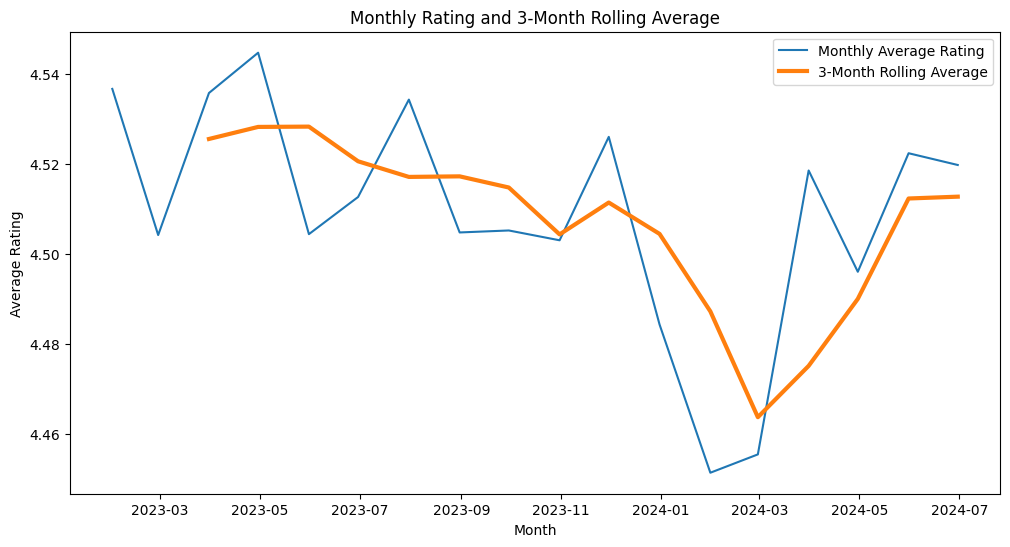

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(monthly_rating, label='Monthly Average Rating')
plt.plot(rolling_rating, label='3-Month Rolling Average', linewidth=3)

plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.title("Monthly Rating and 3-Month Rolling Average")
plt.legend()

plt.show()

#### Customer satisfaction shows a temporary downward trend in early 2024, followed by a strong recovery, so the overall smoothed trend is slightly upward after the dip. The raw monthly line is more volatile and could make the trend look less clear than the 3-month rolling average.

### **Task 07** 

In [29]:
df['heavy_discount'] = df['discount_percent'] > 20

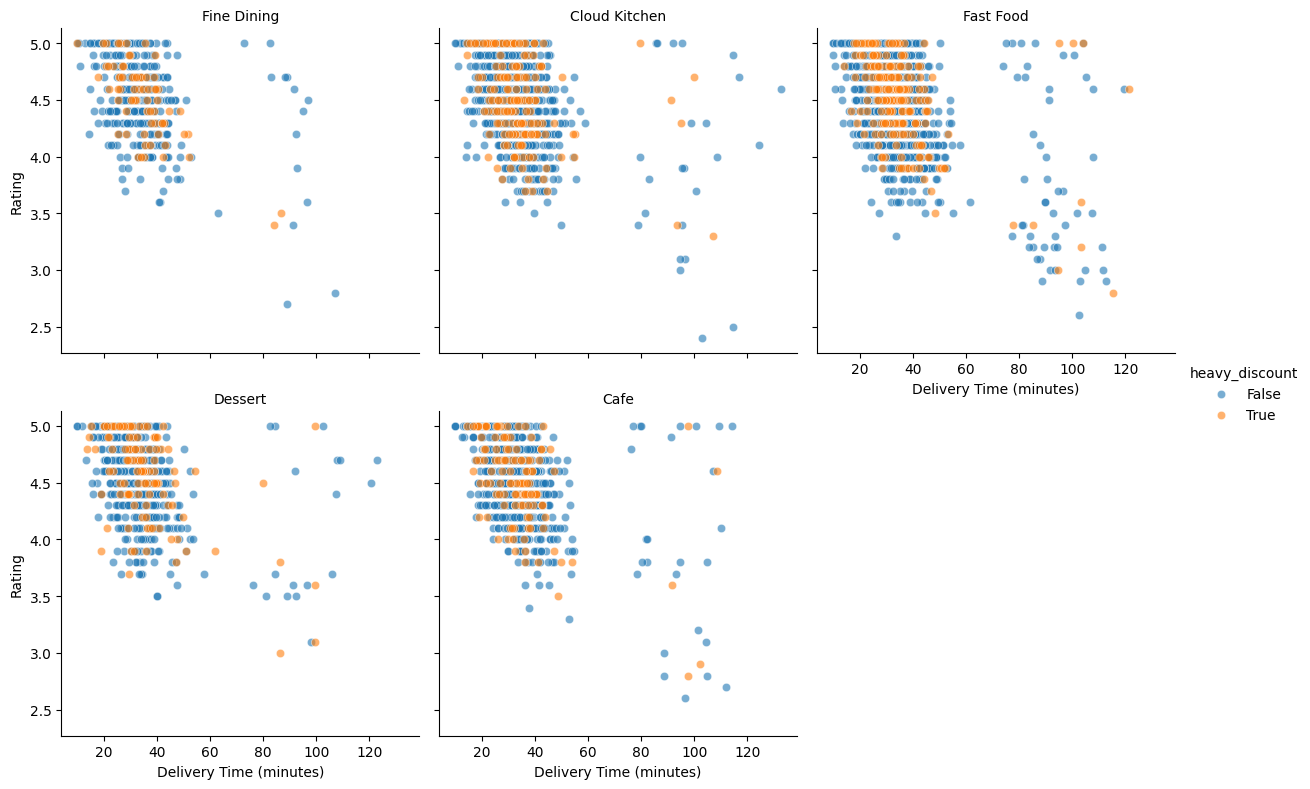

In [30]:
g = sns.FacetGrid(
    df,
    col='restaurant_category',
    hue='heavy_discount',
    col_wrap=3,
    height=4
)

g.map_dataframe(
    sns.scatterplot,
    x='delivery_time_min',
    y='rating',
    alpha=0.6
)

g.add_legend()

g.set_axis_labels("Delivery Time (minutes)", "Rating")
g.set_titles("{col_name}")

plt.show()

#### No restaurant category shows a clear pattern that heavy discounting makes customers more forgiving of slow delivery. Heavy-discounted orders are mostly concentrated at shorter delivery times, while the lowest ratings occur mainly among delayed, non-discounted orders.

### **Task 08** 

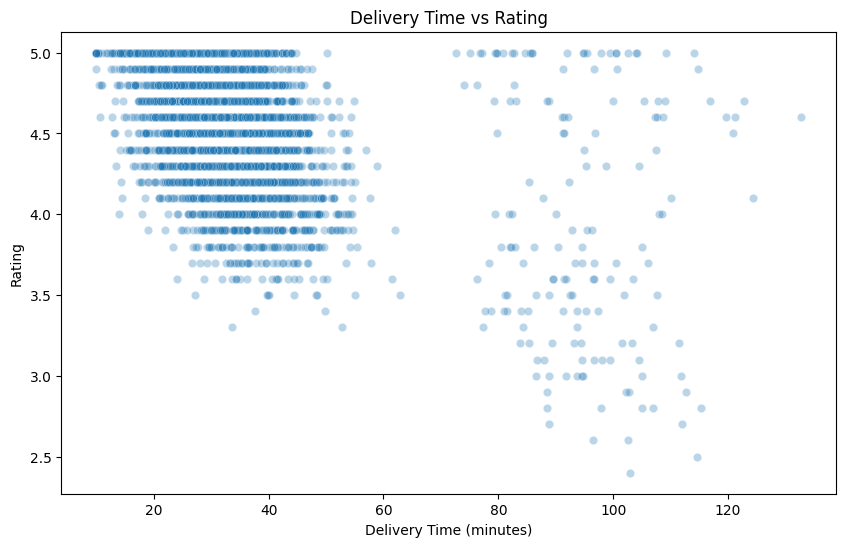

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    alpha=0.3
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating")
plt.show()

In [32]:
print("95th percentile:", df['delivery_time_min'].quantile(0.95))
print("5th percentile:", df['delivery_time_min'].quantile(0.05))

95th percentile: 51.30499999999997
5th percentile: 19.0


In [33]:
long_orders = df[
    df['delivery_time_min'] >= df['delivery_time_min'].quantile(0.95)
]

fast_orders = df[
    df['delivery_time_min'] <= df['delivery_time_min'].quantile(0.05)
]

best_long = long_orders.loc[long_orders['rating'].idxmax()]
worst_fast = fast_orders.loc[fast_orders['rating'].idxmin()]

print("Best rating despite long delivery:")
print(best_long)

print("\nWorst rating despite fast delivery:")
print(worst_fast)

Best rating despite long delivery:
order_date             2023-01-21 00:00:00
city                                Lahore
restaurant_category                   Cafe
cuisine                         Sandwiches
order_value                          341.0
discount_percent                      10.5
delivery_time_min                     79.5
rating                                 5.0
profit_per_order                     -58.0
heavy_discount                       False
Name: 143, dtype: object

Worst rating despite fast delivery:
order_date             2024-02-11 00:00:00
city                             Islamabad
restaurant_category                Dessert
cuisine                              Cakes
order_value                          339.0
discount_percent                      38.2
delivery_time_min                     19.0
rating                                 3.9
profit_per_order                     -15.0
heavy_discount                        True
Name: 3114, dtype: object


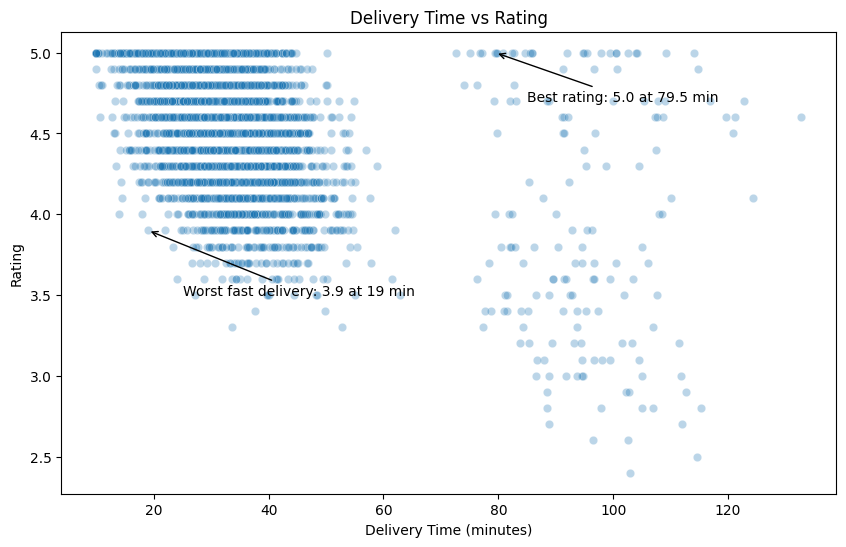

In [34]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='delivery_time_min',
    y='rating',
    alpha=0.3
)

# Best rating despite unusually long delivery
plt.annotate(
    'Best rating: 5.0 at 79.5 min',
    xy=(79.5, 5.0),
    xytext=(85, 4.7),
    arrowprops=dict(arrowstyle='->')
)

# Worst rating despite unusually fast delivery
plt.annotate(
    'Worst fast delivery: 3.9 at 19 min',
    xy=(19, 3.9),
    xytext=(25, 3.5),
    arrowprops=dict(arrowstyle='->')
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating")
plt.show()

#### I used transparency (alpha) because the dataset contains a few thousand orders, so reducing point opacity makes overlapping observations easier to see.